In [2]:
import pandas as pd

df = pd.read_csv("data_core.csv")

df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14
3,32.0,62.0,34.0,Red,Tobacco,22,0,20,28-28
4,28.0,54.0,46.0,Clayey,Paddy,35,0,0,Urea


In [3]:
X = df.drop("Fertilizer Name", axis=1)
y = df["Fertilizer Name"]

In [4]:
X = pd.get_dummies(X)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

In [7]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.135


In [8]:
import joblib

joblib.dump(model, "fertilizer_model.pkl")

['fertilizer_model.pkl']

In [9]:
sample = X.iloc[0:1]

prediction = model.predict(sample)

print("Recommended Fertilizer:", prediction[0])

Recommended Fertilizer: Urea


In [10]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Average accuracy:", scores.mean())

Average accuracy: 0.148375


In [11]:
df["Fertilizer Name"].value_counts()

Fertilizer Name
14-35-14    1188
Urea        1170
DAP         1167
10-26-26    1128
17-17-17    1124
28-28       1120
20-20       1103
Name: count, dtype: int64

In [12]:
df["N_P_ratio"] = df["Nitrogen"] / (df["Phosphorous"] + 1)
df["N_K_ratio"] = df["Nitrogen"] / (df["Potassium"] + 1)
df["P_K_ratio"] = df["Phosphorous"] / (df["Potassium"] + 1)

In [13]:
X = df.drop("Fertilizer Name", axis=1)
y = df["Fertilizer Name"]

X = pd.get_dummies(X)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, pred))

Random Forest Accuracy: 0.144375


In [18]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, pred))

Gradient Boosting Accuracy: 0.138125


In [19]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [20]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

xgb = XGBClassifier(n_estimators=200)
xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred))

XGBoost Accuracy: 0.150625


In [21]:
import joblib

joblib.dump(rf, "fertilizer_model.pkl")

['fertilizer_model.pkl']

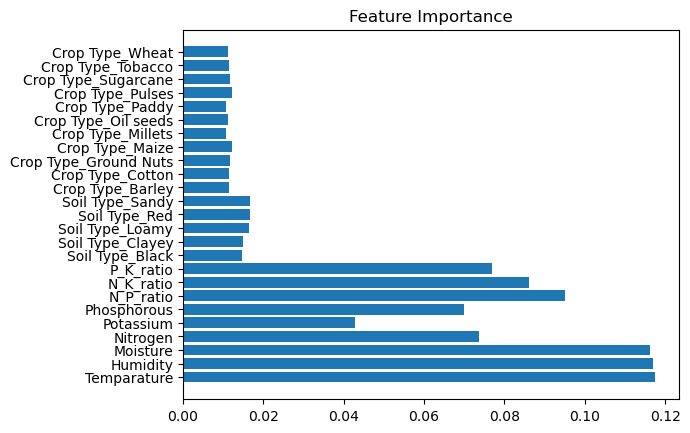

In [22]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [23]:
import pandas as pd

df = pd.read_csv("data_core.csv")

X = df.drop("Fertilizer Name", axis=1)
y = df["Fertilizer Name"]

X = pd.get_dummies(X)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.14625
              precision    recall  f1-score   support

    10-26-26       0.19      0.18      0.19       241
    14-35-14       0.14      0.13      0.13       241
    17-17-17       0.08      0.09      0.09       215
       20-20       0.17      0.14      0.15       236
       28-28       0.14      0.12      0.13       219
         DAP       0.16      0.16      0.16       239
        Urea       0.16      0.19      0.17       209

    accuracy                           0.15      1600
   macro avg       0.15      0.15      0.15      1600
weighted avg       0.15      0.15      0.15      1600



In [28]:
import joblib
joblib.dump(model, "fertilizer_model.pkl")

['fertilizer_model.pkl']

In [29]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.148125


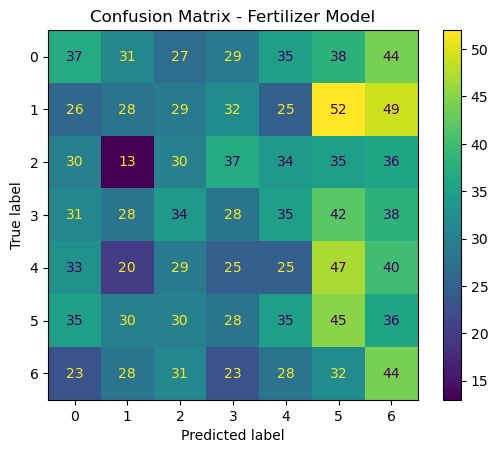

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Fertilizer Model")
plt.show()